# Novel Krylov Protocol Comparison — STO-3G + 6-31G

Hypothesis: a dressed product Krylov basis with **\(N^2\)** vectors can yield size-consistent interaction energies for interacting H₂+H₂, unlike joint QKD with **\(N\)** vectors.

| Protocol | Dimer energy | Subtraction |
|---|---|---|
| **1** | Joint QKD on \(H_{\mathrm{tot}}\) at \(R=1.1\) Å | \(E(R{=}1.1)-E(R{=}1000)\) (both joint QKD) |
| **2** | Same joint QKD at \(R=1.1\) Å | \(E(R{=}1.1)-E_{\mathrm{exact}}(H_a)-E_{\mathrm{exact}}(H_b)\) |
| **3** | Dressed product \(\lvert\Phi_{ij}\rangle=U_A^i U_B^j\lvert\mathrm{HF}\rangle\), size \(N^2\) | Same as Protocol 2 |

**Performance:** 6-31G dimer is 14 qubits (dim \(2^{14}=16384\)). This notebook uses sparse Hamiltonians, `expm_multiply`, one-shot Krylov builds with submatrix slicing, and an \(O(N^2)\) sparse product-grid builder (from `krylov_h2_exact_sc_copy_4.ipynb` / `scripts/step3f_analytic_diagnostics.py`) so it runs on a laptop without dense \(16384\times16384\) factorizations of \(H\).


In [8]:
import gc
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.linalg as la
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh, expm_multiply, norm as sparse_norm

from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_nature.second_q.circuit.library import HartreeFock
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import ParityMapper

warnings.filterwarnings('ignore')

BOND = 0.735
R_LIST = [1000.0, 100.0, 10.0, 1.1]
R_INT = 1.1
R_NONINT = 1000.0
SVD_THRESH = 1e-10
CHEM_ACC = 1.6e-3
SPARSE_DIM_THRESHOLD = 256

BASIS_CONFIG = {
    'sto-3g': {'label': 'STO-3G', 'N_MAX': 6},
    '6-31g':  {'label': '6-31G',  'N_MAX': 8},
}
BASIS_LIST = list(BASIS_CONFIG.keys())

ROOT = os.getcwd()
FIG_ROOT = os.path.join(ROOT, 'output', 'krylov_interacting_protocols_multibasis')
os.makedirs(FIG_ROOT, exist_ok=True)


def fig_dir(basis):
    d = os.path.join(FIG_ROOT, basis.replace('-', ''))
    os.makedirs(d, exist_ok=True)
    return d


print('Bases:', BASIS_LIST)
print('Figures ->', FIG_ROOT)


Bases: ['sto-3g', '6-31g']
Figures -> /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_interacting_protocols_multibasis


## 1. Helpers (dense + sparse / fast paths)


In [9]:
def _pauli_support(label):
    n = len(label)
    return {n - 1 - j for j, ch in enumerate(label) if ch != 'I'}


def spectral_norm_sparse(H_sp):
    return float(sparse_norm(H_sp, ord=2))


def compute_dt(H_matrix):
    return np.pi / float(np.linalg.norm(H_matrix, ord=2))


def compute_dt_sparse(H_sp):
    return np.pi / spectral_norm_sparse(H_sp)


def exact_gs_electronic(H_dense=None, H_sp=None):
    if H_sp is not None:
        val, _ = eigsh(H_sp, k=1, which='SA')
        return float(val[0].real)
    return float(np.linalg.eigvalsh(H_dense)[0].real)


def build_sparse_hamiltonian(H_op):
    return H_op.to_matrix(sparse=True).tocsr()


def build_h2_monomer(basis, bond=BOND):
    half = bond / 2.0
    mol = MoleculeInfo(
        symbols=['H', 'H'],
        coords=[(0.0, 0.0, -half), (0.0, 0.0, half)],
        charge=0, multiplicity=1,
    )
    problem = PySCFDriver.from_molecule(mol, basis=basis).run()
    mapper = ParityMapper(num_particles=problem.num_particles)
    H_op = mapper.map(problem.hamiltonian.second_q_op())
    H = H_op.to_matrix().astype(complex)
    gs_elec = float(np.linalg.eigvalsh(H)[0].real)
    hf = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
    )
    ref = np.array(Statevector(hf.decompose()).data, dtype=complex)
    return {
        'H': H, 'H_op': H_op, 'ref': ref,
        'E_nuc': problem.nuclear_repulsion_energy,
        'n_qubits': H_op.num_qubits,
        'gs_elec': gs_elec,
        'gs_total': gs_elec + problem.nuclear_repulsion_energy,
        'basis': basis,
    }


def build_h2_dimer(R_angstrom, basis, bond=BOND):
    b2 = bond / 2.0
    zA, zB = -R_angstrom / 2.0, R_angstrom / 2.0
    mol = MoleculeInfo(
        symbols=['H', 'H', 'H', 'H'],
        coords=[
            (0.0, 0.0, zA - b2), (0.0, 0.0, zA + b2),
            (0.0, 0.0, zB - b2), (0.0, 0.0, zB + b2),
        ],
        charge=0, multiplicity=1,
    )
    problem = PySCFDriver.from_molecule(mol, basis=basis).run()
    mapper = ParityMapper(num_particles=problem.num_particles)
    H_op = mapper.map(problem.hamiltonian.second_q_op())
    joint_dim = 2 ** H_op.num_qubits
    use_sparse = joint_dim > SPARSE_DIM_THRESHOLD
    H_sp = build_sparse_hamiltonian(H_op) if use_sparse else None
    H = None if use_sparse else H_op.to_matrix().astype(complex)
    gs_elec = exact_gs_electronic(H_dense=H, H_sp=H_sp)
    hf = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper,
    )
    ref = np.array(Statevector(hf.decompose()).data, dtype=complex)
    return {
        'H': H, 'H_op': H_op, 'H_sp': H_sp, 'ref': ref,
        'E_nuc': problem.nuclear_repulsion_energy,
        'n_qubits': H_op.num_qubits, 'joint_dim': joint_dim,
        'gs_elec': gs_elec,
        'gs_total': gs_elec + problem.nuclear_repulsion_energy,
        'R': R_angstrom, 'use_sparse': use_sparse, 'basis': basis,
    }


def partition_hamiltonian(H_op, qubits_a, qubits_b, use_sparse=False):
    qa, qb = set(qubits_a), set(qubits_b)
    pa, pb, pab, ca, cb, cab = [], [], [], [], [], []
    for pauli, coeff in zip(H_op.paulis, H_op.coeffs):
        label = pauli.to_label()
        sup = _pauli_support(label)
        c = complex(coeff)
        if sup <= qa:
            pa.append(label); ca.append(c)
        elif sup <= qb:
            pb.append(label); cb.append(c)
        else:
            pab.append(label); cab.append(c)

    def to_op(labels, coeffs):
        n = 2 ** H_op.num_qubits
        if not labels:
            return csr_matrix((n, n), dtype=complex) if use_sparse else np.zeros((n, n), dtype=complex)
        op = SparsePauliOp.from_list(list(zip(labels, coeffs)))
        return op.to_matrix(sparse=True).tocsr() if use_sparse else op.to_matrix().astype(complex)

    H_a, H_b, H_ab = to_op(pa, ca), to_op(pb, cb), to_op(pab, cab)
    if use_sparse:
        H_tot = H_op.to_matrix(sparse=True).tocsr()
        residual = spectral_norm_sparse(H_tot - (H_a + H_b + H_ab))
    else:
        H_tot = H_op.to_matrix().astype(complex)
        residual = float(np.linalg.norm(H_tot - H_a - H_b - H_ab, ord=2))
    return {'H_a': H_a, 'H_b': H_b, 'H_ab': H_ab, 'H_tot': H_tot, 'residual': residual}


def build_dressed(H_a, H_b, H_ab):
    return H_a + 0.5 * H_ab, H_b + 0.5 * H_ab


def build_krylov_states(H_matrix, psi_ref, krylov_dim, dt):
    U = la.expm(-1j * H_matrix * dt)
    states = [psi_ref.copy().astype(complex)]
    for _ in range(1, krylov_dim):
        states.append(U @ states[-1])
    return states


def build_krylov_states_sparse(H_sp, psi_ref, krylov_dim, dt):
    # Fast sparse chain: iterative expm_multiply (copy_4 / step3f).
    states = [psi_ref.copy().astype(complex)]
    for _ in range(1, krylov_dim):
        states.append(expm_multiply(-1j * dt * H_sp, states[-1]))
    return states


def build_krylov_matrices(H_matrix, states):
    Psi = np.column_stack(states)
    S = Psi.conj().T @ Psi
    Ht = Psi.conj().T @ (H_matrix @ Psi)
    return S, Ht


def build_krylov_projected_sparse(H_sp, states):
    # Project sparse H into Krylov subspace without densifying H (copy_4).
    Psi = np.column_stack(states)
    S = Psi.conj().T @ Psi
    Ht = Psi.conj().T @ (H_sp @ Psi)
    return S, Ht


def build_product_states_dense(H_A, H_B, ref, N, dt):
    U_A = la.expm(-1j * dt * H_A)
    U_B = la.expm(-1j * dt * H_B)
    b_chain = [ref.copy().astype(complex)]
    for _ in range(1, N):
        b_chain.append(U_B @ b_chain[-1])
    a_chain = [np.eye(H_A.shape[0], dtype=complex)]
    for _ in range(1, N):
        a_chain.append(U_A @ a_chain[-1])
    return [a_chain[i] @ b_chain[j] for i in range(N) for j in range(N)]


def build_product_states_sparse(H_A_sp, H_B_sp, ref, N, dt):
    # O(N^2) sparse product grid: |Phi_ij> = U_A^i U_B^j |ref>.
    # Layer-by-layer U_A application: N + N(N-1) = N^2 matvecs.
    ref = ref.astype(complex)
    b_chain = [ref.copy()]
    for _ in range(1, N):
        b_chain.append(expm_multiply(-1j * dt * H_B_sp, b_chain[-1]))
    curr = list(b_chain)
    states = []
    for i in range(N):
        states.extend(curr)
        if i < N - 1:
            curr = [expm_multiply(-1j * dt * H_A_sp, s) for s in curr]
    return states


def solve_gen_eig(H_tilde, S_tilde, threshold=SVD_THRESH):
    s_vals, s_vecs = la.eigh(S_tilde)
    s_vecs = s_vecs.T
    good = np.array([v for val, v in zip(s_vals, s_vecs) if val > threshold])
    if len(good) == 0:
        return np.nan, 0
    H_reg = good.conj() @ H_tilde @ good.T
    S_reg = good.conj() @ S_tilde @ good.T
    e_gs = float(la.eigh(H_reg, S_reg)[0][0].real)
    return e_gs, len(good)


def energy_from_states(H_or_sp, states, E_nuc, use_sparse=False, threshold=SVD_THRESH):
    if use_sparse:
        S, Ht = build_krylov_projected_sparse(H_or_sp, states)
    else:
        S, Ht = build_krylov_matrices(H_or_sp, states)
    gs_elec, eff_dim = solve_gen_eig(Ht, S, threshold)
    return {
        'gs_elec': gs_elec,
        'gs_total': gs_elec + E_nuc,
        'eff_dim': eff_dim,
        'raw_dim': len(states),
        'S': S,
        'H': Ht,
    }


def build_all_systems(basis, R_list):
    mono = build_h2_monomer(basis)
    qa = list(range(mono['n_qubits']))
    qb = list(range(mono['n_qubits'], 2 * mono['n_qubits']))
    systems = {}
    for R in R_list:
        dim = build_h2_dimer(R, basis)
        us = dim['use_sparse']
        part = partition_hamiltonian(dim['H_op'], qa, qb, use_sparse=us)
        H_A, H_B = build_dressed(part['H_a'], part['H_b'], part['H_ab'])
        if us:
            dress_res = spectral_norm_sparse(part['H_tot'] - H_A - H_B)
            norm_ab = spectral_norm_sparse(part['H_ab'])
            dt_tot = compute_dt_sparse(part['H_tot'])
        else:
            dress_res = float(np.linalg.norm(H_A + H_B - part['H_tot'], 2))
            norm_ab = float(np.linalg.norm(part['H_ab'], 2))
            dt_tot = compute_dt(part['H_tot'])
        sys = {
            **dim, **part,
            'H_A': H_A, 'H_B': H_B,
            'E_exact_sum': 2.0 * mono['gs_total'],
            'delta_exact': dim['gs_total'] - 2.0 * mono['gs_total'],
            'dress_residual': dress_res,
            'dt_tot': dt_tot,
            'dt_mono': compute_dt(mono['H']),
            'qubits_a': qa, 'qubits_b': qb,
            'norm_H_ab': norm_ab,
        }
        if us:
            sys['H_tot_sp'] = part['H_tot']
            sys['H_A_sp'] = H_A
            sys['H_B_sp'] = H_B
        systems[R] = sys
        gc.collect()
    return mono, systems


print('Helpers ready (dense + sparse fast paths).')


Helpers ready (dense + sparse fast paths).


## 2. Fast protocol sweeps

- **Joint:** build Krylov chain once at \(N_{\max}\), form \(S,H\) once, slice for each \(N\) (copy_4 style).
- **Novel:** build product grid once at \(N_{\max}\) (\(N_{\max}^2\) states); for each \(N\) extract the \((i,j)<N\) block.


In [10]:
def _H_tot_of(sys):
    return sys['H_tot_sp'] if sys['use_sparse'] else sys['H_tot']


def _H_A_of(sys):
    return sys['H_A_sp'] if sys['use_sparse'] else sys['H_A']


def _H_B_of(sys):
    return sys['H_B_sp'] if sys['use_sparse'] else sys['H_B']


def sweep_joint(sys, dims):
    # One-shot joint chain at max(dims); slice submatrices (copy_4 style).
    max_n = max(dims)
    H = _H_tot_of(sys)
    if sys['use_sparse']:
        states = build_krylov_states_sparse(H, sys['ref'], max_n, sys['dt_tot'])
        S_full, H_full = build_krylov_projected_sparse(H, states)
    else:
        states = build_krylov_states(H, sys['ref'], max_n, sys['dt_tot'])
        S_full, H_full = build_krylov_matrices(H, states)
    rows = []
    for N in dims:
        gs_elec, eff = solve_gen_eig(H_full[:N, :N], S_full[:N, :N])
        rows.append({
            'N': N, 'raw_dim': N, 'eff_dim': eff,
            'gs_total': gs_elec + sys['E_nuc'],
            'gs_err': abs(gs_elec + sys['E_nuc'] - sys['gs_total']),
        })
    return pd.DataFrame(rows)


def sweep_novel(sys, dims):
    # One-shot dressed product grid at max N; extract N x N blocks.
    max_n = max(dims)
    H = _H_tot_of(sys)
    HA, HB = _H_A_of(sys), _H_B_of(sys)
    if sys['use_sparse']:
        states_full = build_product_states_sparse(HA, HB, sys['ref'], max_n, sys['dt_tot'])
        S_full, H_full = build_krylov_projected_sparse(H, states_full)
    else:
        states_full = build_product_states_dense(HA, HB, sys['ref'], max_n, sys['dt_tot'])
        S_full, H_full = build_krylov_matrices(H, states_full)
    assert len(states_full) == max_n * max_n

    rows = []
    for N in dims:
        # Layer-major order: index = i*max_n + j
        idx = [i * max_n + j for i in range(N) for j in range(N)]
        S = S_full[np.ix_(idx, idx)]
        Ht = H_full[np.ix_(idx, idx)]
        gs_elec, eff = solve_gen_eig(Ht, S)
        gs_total = gs_elec + sys['E_nuc']
        rows.append({
            'N': N, 'raw_dim': N * N, 'eff_dim': eff,
            'gs_total': gs_total,
            'gs_err': abs(gs_total - sys['gs_total']),
        })
    return pd.DataFrame(rows)


def energy_at_N(sys, N, procedure):
    H = _H_tot_of(sys)
    if procedure == 'novel':
        HA, HB = _H_A_of(sys), _H_B_of(sys)
        if sys['use_sparse']:
            states = build_product_states_sparse(HA, HB, sys['ref'], N, sys['dt_tot'])
        else:
            states = build_product_states_dense(HA, HB, sys['ref'], N, sys['dt_tot'])
        assert len(states) == N * N
    else:
        if sys['use_sparse']:
            states = build_krylov_states_sparse(H, sys['ref'], N, sys['dt_tot'])
        else:
            states = build_krylov_states(H, sys['ref'], N, sys['dt_tot'])
    return energy_from_states(H, states, sys['E_nuc'], use_sparse=sys['use_sparse'])


print('Sweep helpers ready.')


Sweep helpers ready.


## 3. Run both bases: build systems, protocols, SC diagnostics


In [11]:
results = {}  # basis -> dict of dataframes / scalars

for basis in BASIS_LIST:
    cfg = BASIS_CONFIG[basis]
    N_MAX = cfg['N_MAX']
    DIMS = list(range(1, N_MAX + 1))
    out = fig_dir(basis)
    print('=' * 60)
    print(f"{cfg['label']}  |  N_MAX={N_MAX}  |  out={out}")
    print('=' * 60)

    mono, systems = build_all_systems(basis, R_LIST)
    E_mono = mono['gs_total']
    E_mono_sum = 2.0 * E_mono
    delta_exact = systems[R_INT]['delta_exact']

    for R, sys in systems.items():
        print(
            f"  R={R:7.1f} | dim={sys['joint_dim']:5d} | sparse={sys['use_sparse']} | "
            f"E={sys['gs_total']:+.8f} | dE={sys['delta_exact']:+.3e} | "
            f"||Hab||={sys['norm_H_ab']:.2e}"
        )
    print(f"  E_mono={E_mono:.10f}  |  delta_exact(1.1)={delta_exact:.10f}")

    # Basis-size check at R=1.1
    sys_int = systems[R_INT]
    basis_rows = []
    H = _H_tot_of(sys_int)
    for N in DIMS:
        if sys_int['use_sparse']:
            joint = build_krylov_states_sparse(H, sys_int['ref'], N, sys_int['dt_tot'])
            novel = build_product_states_sparse(
                _H_A_of(sys_int), _H_B_of(sys_int), sys_int['ref'], N, sys_int['dt_tot'])
            S_nov = build_krylov_projected_sparse(H, novel)[0]
        else:
            joint = build_krylov_states(H, sys_int['ref'], N, sys_int['dt_tot'])
            novel = build_product_states_dense(
                sys_int['H_A'], sys_int['H_B'], sys_int['ref'], N, sys_int['dt_tot'])
            S_nov = build_krylov_matrices(H, novel)[0]
        assert len(joint) == N and len(novel) == N * N
        eff = int(np.sum(np.linalg.eigvalsh(S_nov).real > SVD_THRESH))
        basis_rows.append({
            'N': N, 'joint_raw_dim': N, 'novel_raw_dim': N * N,
            'novel_N2': N * N, 'novel_eff_dim': eff,
        })
        print(f"  N={N}: joint={N:2d} | novel={N*N:3d} (=N^2) | eff={eff}")
    df_basis = pd.DataFrame(basis_rows)
    df_basis.to_csv(os.path.join(out, 'basis_size_check.csv'), index=False)

    # Protocol sweeps
    print('  Sweeping joint / novel ...')
    df_joint_int = sweep_joint(systems[R_INT], DIMS)
    df_joint_non = sweep_joint(systems[R_NONINT], DIMS)
    df_novel_int = sweep_novel(systems[R_INT], DIMS)

    protocol_rows = []
    for N in DIMS:
        E_j_int = float(df_joint_int.loc[df_joint_int['N'] == N, 'gs_total'].iloc[0])
        E_j_non = float(df_joint_non.loc[df_joint_non['N'] == N, 'gs_total'].iloc[0])
        E_nov = float(df_novel_int.loc[df_novel_int['N'] == N, 'gs_total'].iloc[0])
        d1 = E_j_int - E_j_non
        d2 = E_j_int - E_mono_sum
        d3 = E_nov - E_mono_sum
        protocol_rows.append({
            'basis': basis, 'N': N,
            'E_joint_R1p1': E_j_int, 'E_joint_R1000': E_j_non, 'E_novel_R1p1': E_nov,
            'novel_raw_dim': N * N,
            'delta_P1': d1, 'delta_P2': d2, 'delta_P3': d3,
            'err_P1': abs(d1 - delta_exact),
            'err_P2': abs(d2 - delta_exact),
            'err_P3': abs(d3 - delta_exact),
            'gs_err_joint': float(df_joint_int.loc[df_joint_int['N'] == N, 'gs_err'].iloc[0]),
            'gs_err_novel': float(df_novel_int.loc[df_novel_int['N'] == N, 'gs_err'].iloc[0]),
            'eff_dim_joint': int(df_joint_int.loc[df_joint_int['N'] == N, 'eff_dim'].iloc[0]),
            'eff_dim_novel': int(df_novel_int.loc[df_novel_int['N'] == N, 'eff_dim'].iloc[0]),
        })
    df_proto = pd.DataFrame(protocol_rows)
    df_proto.to_csv(os.path.join(out, 'protocol_sweep_R1p1.csv'), index=False)
    p1_ne_p2 = not np.allclose(df_proto['delta_P1'], df_proto['delta_P2'])
    print(df_proto[['N', 'novel_raw_dim', 'err_P1', 'err_P2', 'err_P3']].to_string(
        index=False, float_format=lambda x: f'{x:.3e}'))
    print(f'  P1 != P2? {p1_ne_p2}')

    # SC diagnostic (finite-N monomers)
    print('  SC diagnostic at R=1000 ...')
    states_m = build_krylov_states(mono['H'], mono['ref'], N_MAX, compute_dt(mono['H']))
    S_m, H_m = build_krylov_matrices(mono['H'], states_m)
    mono_qkd = []
    for N in DIMS:
        gs_elec, eff = solve_gen_eig(H_m[:N, :N], S_m[:N, :N])
        mono_qkd.append({'N': N, 'E_mono_qkd': gs_elec + mono['E_nuc']})
    df_mono_qkd = pd.DataFrame(mono_qkd)
    df_novel_non = sweep_novel(systems[R_NONINT], DIMS)

    sc_rows = []
    for N in DIMS:
        E_j = float(df_joint_non.loc[df_joint_non['N'] == N, 'gs_total'].iloc[0])
        E_nov = float(df_novel_non.loc[df_novel_non['N'] == N, 'gs_total'].iloc[0])
        E_m = float(df_mono_qkd.loc[df_mono_qkd['N'] == N, 'E_mono_qkd'].iloc[0])
        two_m = 2.0 * E_m
        E_j_int = float(df_joint_int.loc[df_joint_int['N'] == N, 'gs_total'].iloc[0])
        d1 = float(df_proto.loc[df_proto['N'] == N, 'delta_P1'].iloc[0])
        d2 = float(df_proto.loc[df_proto['N'] == N, 'delta_P2'].iloc[0])
        d2q = E_j_int - two_m
        sc_rows.append({
            'basis': basis, 'N': N,
            'E_joint_R1000': E_j, 'E_novel_R1000': E_nov,
            'E_mono_qkd': E_m, 'two_E_mono_qkd': two_m,
            'two_E_mono_exact': E_mono_sum,
            'SC_err_joint': abs(E_j - two_m),
            'SC_err_novel': abs(E_nov - two_m),
            'ref_gap_P1_vs_P2': abs(E_j - E_mono_sum),
            'delta_P1': d1, 'delta_P2_exact': d2, 'delta_P2_qkd': d2q,
            'err_P1': abs(d1 - delta_exact),
            'err_P2_exact': abs(d2 - delta_exact),
            'err_P2_qkd': abs(d2q - delta_exact),
        })
    df_sc = pd.DataFrame(sc_rows)
    df_sc.to_csv(os.path.join(out, 'size_consistency_diagnostic.csv'), index=False)
    print(f"  SC_err_joint peak={df_sc['SC_err_joint'].max():.3e}  |  "
          f"novel SC at Nmax={df_sc.loc[df_sc['N']==N_MAX,'SC_err_novel'].iloc[0]:.3e}")

    # R-sweep at N_MAX
    print(f'  R-sweep at N={N_MAX} ...')
    E_joint_non_fixed = float(df_joint_non.loc[df_joint_non['N'] == N_MAX, 'gs_total'].iloc[0])
    r_rows = []
    for R in R_LIST:
        sys = systems[R]
        out_j = energy_at_N(sys, N_MAX, 'joint')
        out_n = energy_at_N(sys, N_MAX, 'novel')
        d_ex = sys['delta_exact']
        d1 = out_j['gs_total'] - E_joint_non_fixed
        d2 = out_j['gs_total'] - E_mono_sum
        d3 = out_n['gs_total'] - E_mono_sum
        r_rows.append({
            'basis': basis, 'R': R, 'N': N_MAX,
            'E_exact': sys['gs_total'],
            'E_joint': out_j['gs_total'], 'E_novel': out_n['gs_total'],
            'delta_exact': d_ex, 'delta_P1': d1, 'delta_P2': d2, 'delta_P3': d3,
            'err_P1': abs(d1 - d_ex), 'err_P2': abs(d2 - d_ex), 'err_P3': abs(d3 - d_ex),
            'novel_raw_dim': N_MAX * N_MAX,
        })
        gc.collect()
    df_R = pd.DataFrame(r_rows)
    df_R.to_csv(os.path.join(out, 'interaction_vs_R.csv'), index=False)

    results[basis] = {
        'E_mono': E_mono, 'E_mono_sum': E_mono_sum, 'delta_exact': delta_exact,
        'N_MAX': N_MAX, 'DIMS': DIMS, 'out': out,
        'df_basis': df_basis, 'df_proto': df_proto, 'df_sc': df_sc, 'df_R': df_R,
        'p1_ne_p2': p1_ne_p2,
        'dimer_dim': systems[R_INT]['joint_dim'],
        'use_sparse': systems[R_INT]['use_sparse'],
    }
    del systems, mono
    gc.collect()
    print(f'  Done {cfg["label"]}.\n')

pd.concat([results[b]['df_proto'] for b in BASIS_LIST], ignore_index=True).to_csv(
    os.path.join(FIG_ROOT, 'protocol_sweep_all.csv'), index=False)
pd.concat([results[b]['df_sc'] for b in BASIS_LIST], ignore_index=True).to_csv(
    os.path.join(FIG_ROOT, 'size_consistency_all.csv'), index=False)
pd.concat([results[b]['df_R'] for b in BASIS_LIST], ignore_index=True).to_csv(
    os.path.join(FIG_ROOT, 'interaction_vs_R_all.csv'), index=False)
print('Combined CSVs written to', FIG_ROOT)


STO-3G  |  N_MAX=6  |  out=/home/desai/School/trinity-term/qkd-size-consistency/output/krylov_interacting_protocols_multibasis/sto3g
  R= 1000.0 | dim=   64 | sparse=False | E=-2.27461207 | dE=+1.155e-14 | ||Hab||=2.18e+00
  R=  100.0 | dim=   64 | sparse=False | E=-2.27461207 | dE=+2.043e-12 | ||Hab||=2.19e+00
  R=   10.0 | dim=   64 | sparse=False | E=-2.27461195 | dE=+1.236e-07 | ||Hab||=2.44e+00
  R=    1.1 | dim=   64 | sparse=False | E=-1.62751587 | dE=+6.471e-01 | ||Hab||=5.02e+00
  E_mono=-1.1373060358  |  delta_exact(1.1)=0.6470961966
  N=1: joint= 1 | novel=  1 (=N^2) | eff=1
  N=2: joint= 2 | novel=  4 (=N^2) | eff=4
  N=3: joint= 3 | novel=  9 (=N^2) | eff=9
  N=4: joint= 4 | novel= 16 (=N^2) | eff=16
  N=5: joint= 5 | novel= 25 (=N^2) | eff=21
  N=6: joint= 6 | novel= 36 (=N^2) | eff=25
  Sweeping joint / novel ...
 N  novel_raw_dim    err_P1    err_P2    err_P3
 1              1 5.977e-03 4.659e-02 4.659e-02
 2              4 1.832e-02 1.882e-02 6.066e-03
 3              

## 4. Per-basis plots


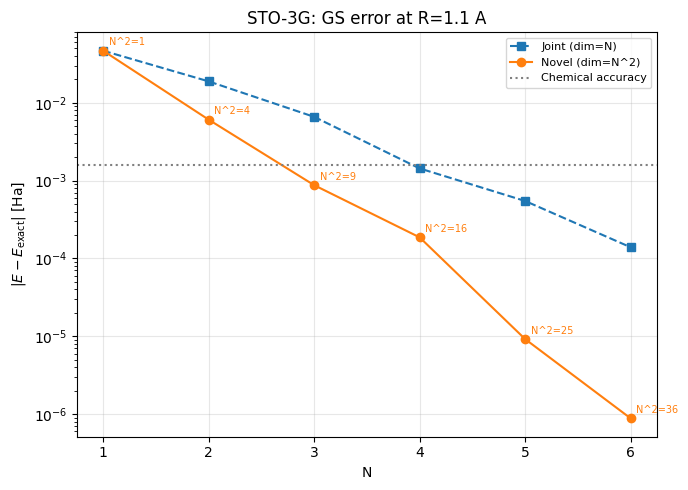

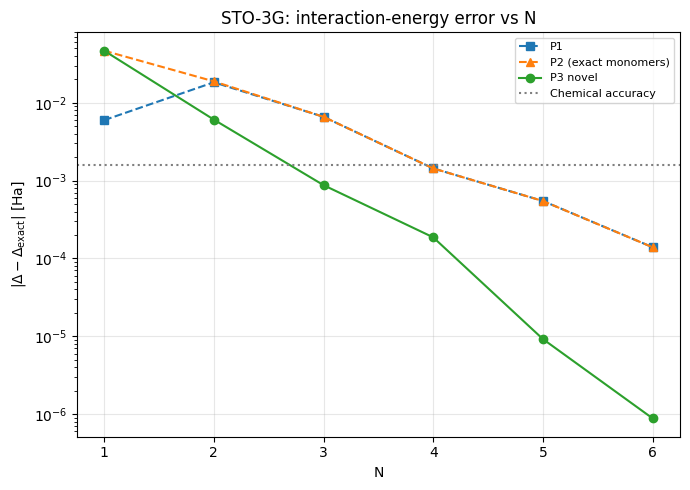

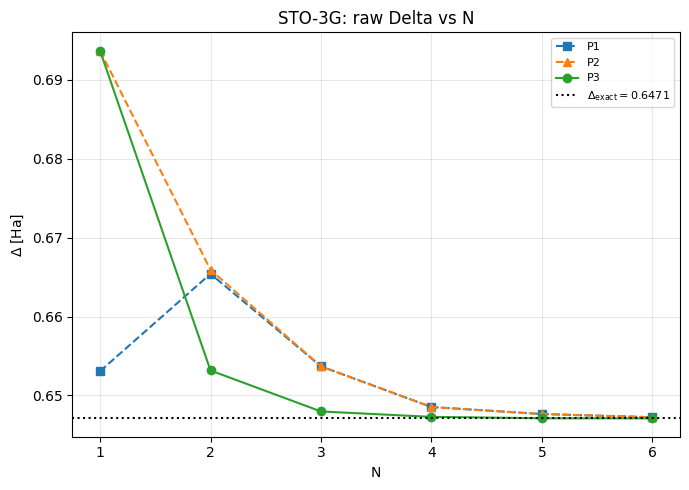

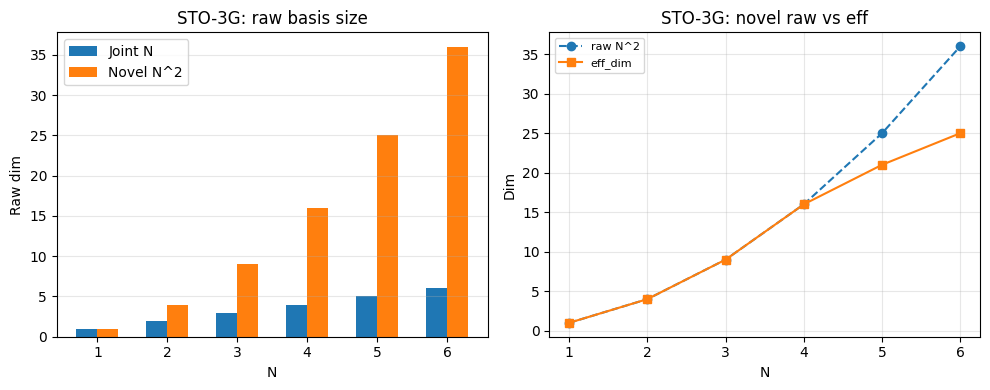

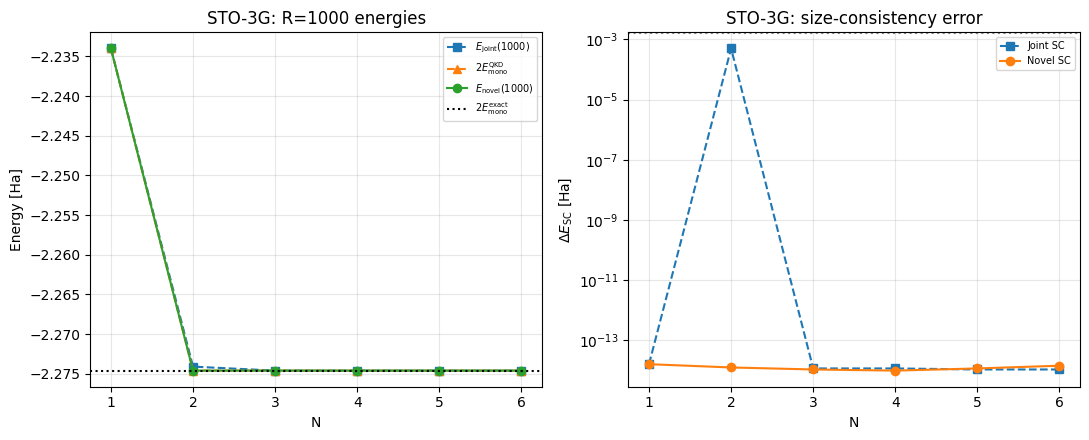

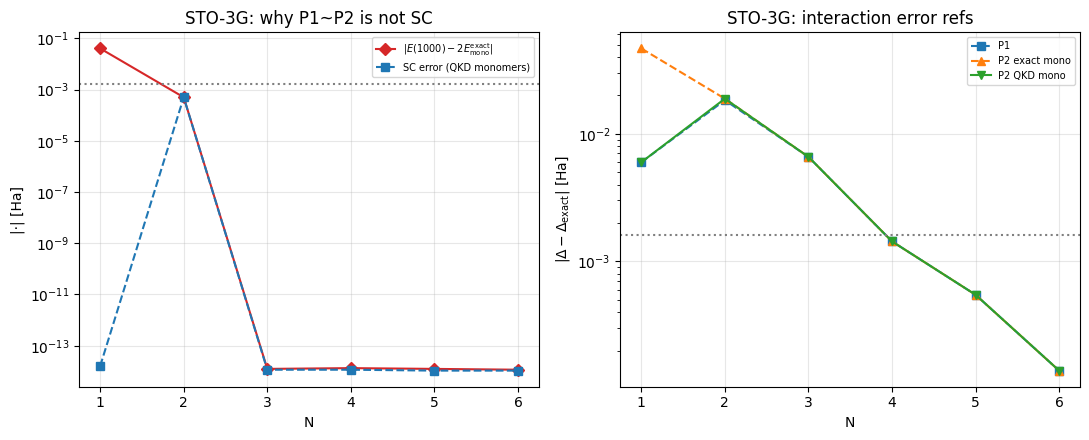

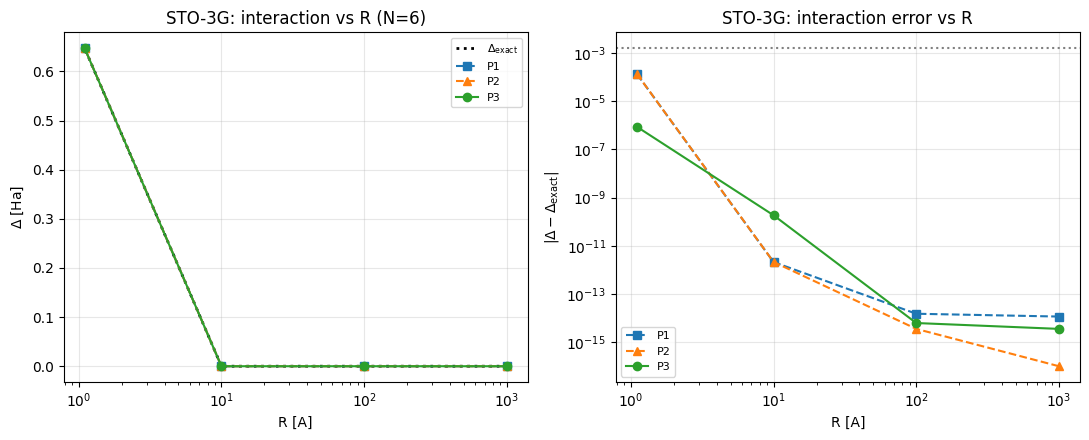

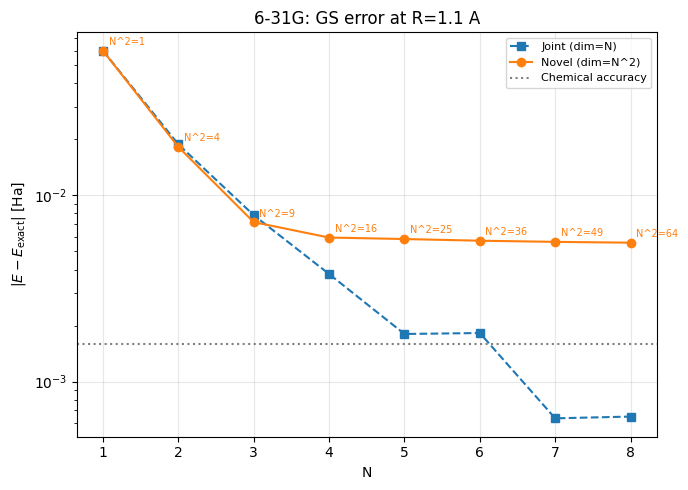

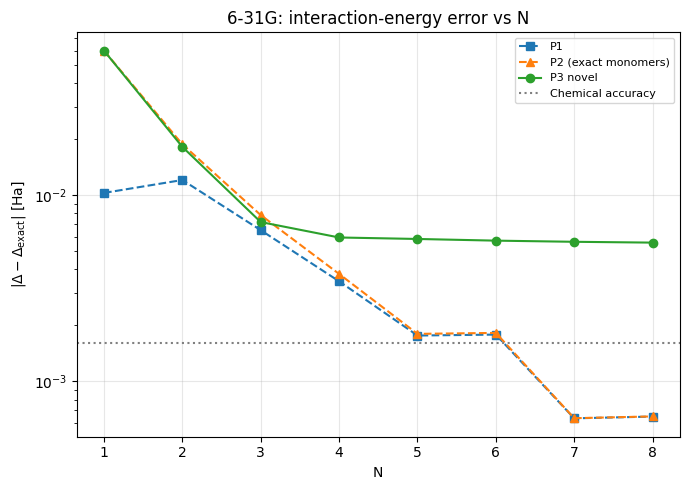

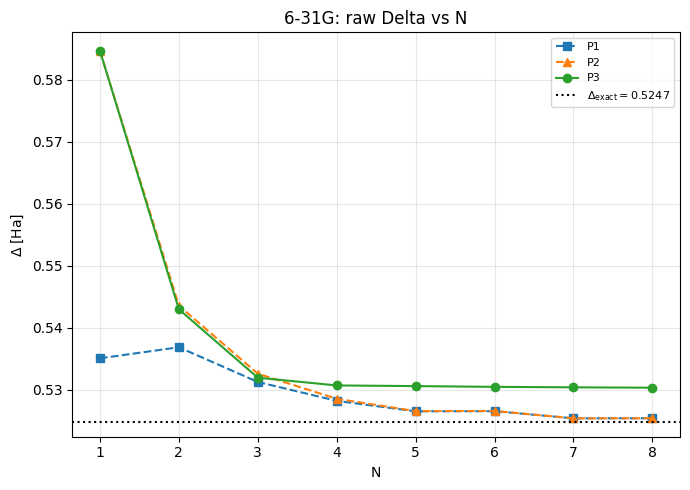

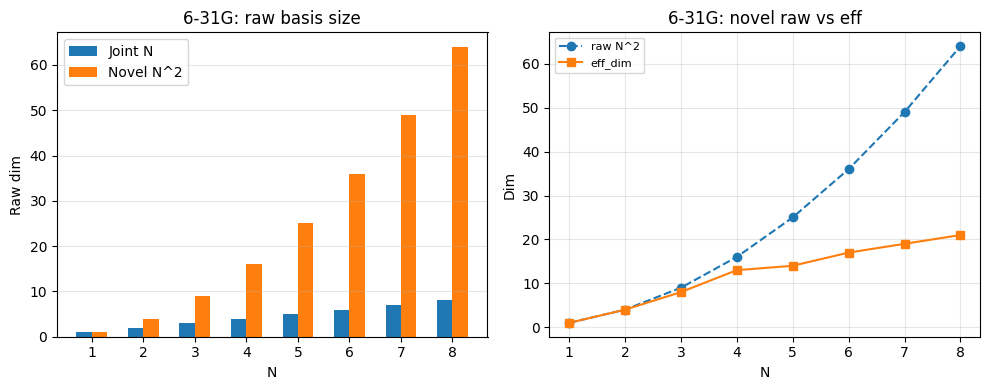

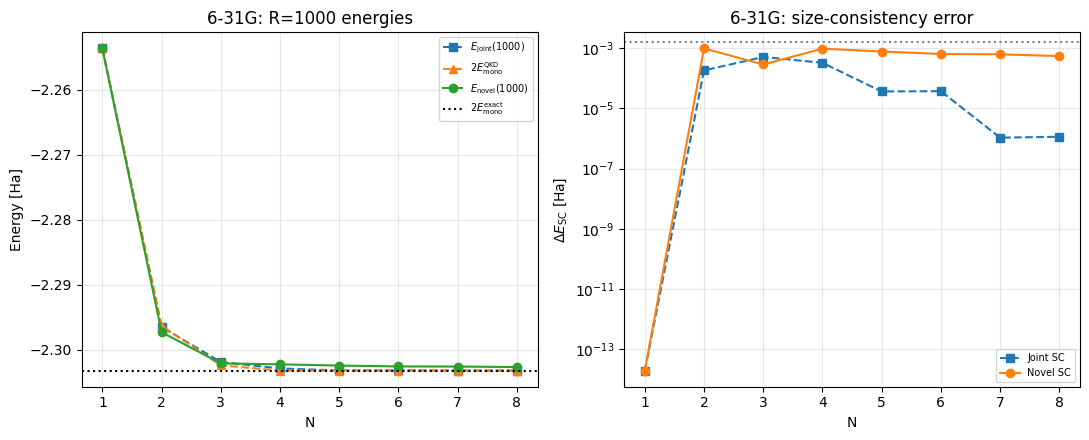

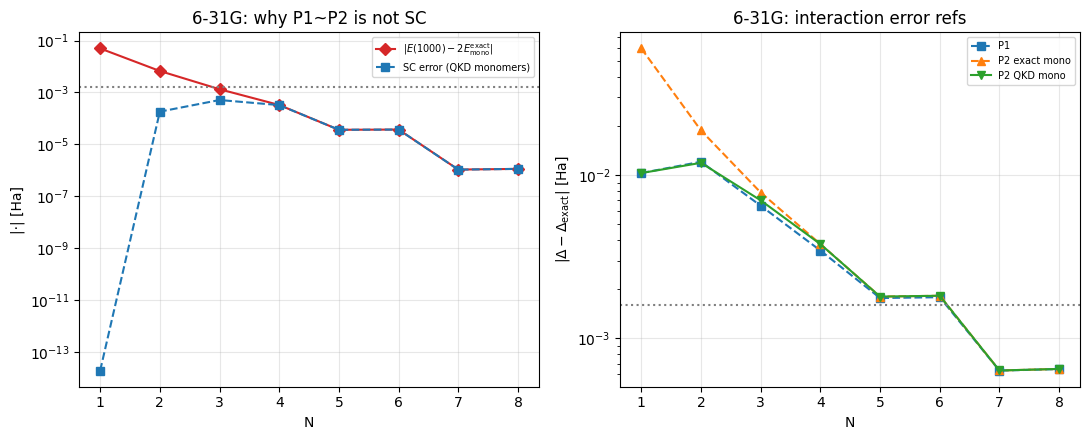

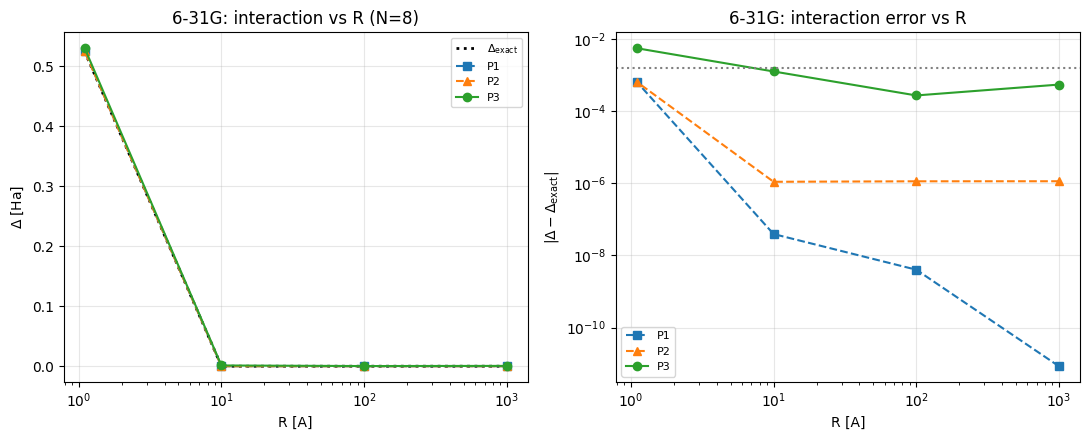

In [12]:
for basis in BASIS_LIST:
    cfg = BASIS_CONFIG[basis]
    r = results[basis]
    out, df_proto, df_sc, df_R, df_basis = (
        r['out'], r['df_proto'], r['df_sc'], r['df_R'], r['df_basis']
    )
    delta_exact, N_MAX = r['delta_exact'], r['N_MAX']
    label = cfg['label']

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.semilogy(df_proto['N'], df_proto['gs_err_joint'], 's--', label='Joint (dim=N)')
    ax.semilogy(df_proto['N'], df_proto['gs_err_novel'], 'o-', label='Novel (dim=N^2)')
    for _, row in df_proto.iterrows():
        ax.annotate(
            f"N^2={int(row['novel_raw_dim'])}",
            (row['N'], max(row['gs_err_novel'], 1e-16)),
            textcoords='offset points', xytext=(4, 4), fontsize=7, color='C1',
        )
    ax.axhline(CHEM_ACC, color='gray', ls=':', label='Chemical accuracy')
    ax.set_xlabel('N'); ax.set_ylabel(r'$|E-E_{\mathrm{exact}}|$ [Ha]')
    ax.set_title(f'{label}: GS error at R=1.1 A')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.tight_layout(); fig.savefig(os.path.join(out, 'gs_error_vs_N.png'), dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.semilogy(df_proto['N'], df_proto['err_P1'], 's--', label='P1')
    ax.semilogy(df_proto['N'], df_proto['err_P2'], '^--', label='P2 (exact monomers)')
    ax.semilogy(df_proto['N'], df_proto['err_P3'], 'o-', label='P3 novel')
    ax.axhline(CHEM_ACC, color='gray', ls=':', label='Chemical accuracy')
    ax.set_xlabel('N'); ax.set_ylabel(r'$|\Delta-\Delta_{\mathrm{exact}}|$ [Ha]')
    ax.set_title(f'{label}: interaction-energy error vs N')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.tight_layout(); fig.savefig(os.path.join(out, 'protocol_interaction_error_vs_N.png'), dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(df_proto['N'], df_proto['delta_P1'], 's--', label='P1')
    ax.plot(df_proto['N'], df_proto['delta_P2'], '^--', label='P2')
    ax.plot(df_proto['N'], df_proto['delta_P3'], 'o-', label='P3')
    ax.axhline(delta_exact, color='k', ls=':', label=rf'$\Delta_{{\mathrm{{exact}}}}={delta_exact:.4f}$')
    ax.set_xlabel('N'); ax.set_ylabel(r'$\Delta$ [Ha]')
    ax.set_title(f'{label}: raw Delta vs N')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.tight_layout(); fig.savefig(os.path.join(out, 'raw_delta_vs_N.png'), dpi=150); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(df_basis['N'] - 0.15, df_basis['joint_raw_dim'], width=0.3, label='Joint N')
    axes[0].bar(df_basis['N'] + 0.15, df_basis['novel_raw_dim'], width=0.3, label='Novel N^2')
    axes[0].set_xlabel('N'); axes[0].set_ylabel('Raw dim'); axes[0].set_title(f'{label}: raw basis size')
    axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
    axes[1].plot(df_basis['N'], df_basis['novel_raw_dim'], 'o--', label='raw N^2')
    axes[1].plot(df_basis['N'], df_basis['novel_eff_dim'], 's-', label='eff_dim')
    axes[1].set_xlabel('N'); axes[1].set_ylabel('Dim'); axes[1].set_title(f'{label}: novel raw vs eff')
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
    fig.tight_layout(); fig.savefig(os.path.join(out, 'basis_dim_check.png'), dpi=150); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    ax = axes[0]
    ax.plot(df_sc['N'], df_sc['E_joint_R1000'], 's--', label=r'$E_{\mathrm{joint}}(1000)$')
    ax.plot(df_sc['N'], df_sc['two_E_mono_qkd'], '^--', label=r'$2E_{\mathrm{mono}}^{\mathrm{QKD}}$')
    ax.plot(df_sc['N'], df_sc['E_novel_R1000'], 'o-', label=r'$E_{\mathrm{novel}}(1000)$')
    ax.axhline(r['E_mono_sum'], color='k', ls=':', label=r'$2E_{\mathrm{mono}}^{\mathrm{exact}}$')
    ax.set_xlabel('N'); ax.set_ylabel('Energy [Ha]'); ax.set_title(f'{label}: R=1000 energies')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.semilogy(df_sc['N'], np.maximum(df_sc['SC_err_joint'], 1e-16), 's--', label='Joint SC')
    ax.semilogy(df_sc['N'], np.maximum(df_sc['SC_err_novel'], 1e-16), 'o-', label='Novel SC')
    ax.axhline(CHEM_ACC, color='gray', ls=':')
    ax.set_xlabel('N'); ax.set_ylabel(r'$\Delta E_{\mathrm{SC}}$ [Ha]')
    ax.set_title(f'{label}: size-consistency error')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    fig.tight_layout(); fig.savefig(os.path.join(out, 'size_consistency_R1000.png'), dpi=150); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    ax = axes[0]
    ax.semilogy(df_sc['N'], np.maximum(df_sc['ref_gap_P1_vs_P2'], 1e-16), 'D-', color='C3',
                label=r'$|E(1000)-2E_{\mathrm{mono}}^{\mathrm{exact}}|$')
    ax.semilogy(df_sc['N'], np.maximum(df_sc['SC_err_joint'], 1e-16), 's--',
                label='SC error (QKD monomers)')
    ax.axhline(CHEM_ACC, color='gray', ls=':')
    ax.set_xlabel('N'); ax.set_ylabel('|·| [Ha]'); ax.set_title(f'{label}: why P1~P2 is not SC')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.semilogy(df_sc['N'], np.maximum(df_sc['err_P1'], 1e-16), 's--', label='P1')
    ax.semilogy(df_sc['N'], np.maximum(df_sc['err_P2_exact'], 1e-16), '^--', label='P2 exact mono')
    ax.semilogy(df_sc['N'], np.maximum(df_sc['err_P2_qkd'], 1e-16), 'v-', label='P2 QKD mono')
    ax.axhline(CHEM_ACC, color='gray', ls=':')
    ax.set_xlabel('N'); ax.set_ylabel(r'$|\Delta-\Delta_{\mathrm{exact}}|$ [Ha]')
    ax.set_title(f'{label}: interaction error refs')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    fig.tight_layout(); fig.savefig(os.path.join(out, 'p1_p2_sc_explanation.png'), dpi=150); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    ax = axes[0]
    ax.plot(df_R['R'], df_R['delta_exact'], 'k:', lw=2, label=r'$\Delta_{\mathrm{exact}}$')
    ax.plot(df_R['R'], df_R['delta_P1'], 's--', label='P1')
    ax.plot(df_R['R'], df_R['delta_P2'], '^--', label='P2')
    ax.plot(df_R['R'], df_R['delta_P3'], 'o-', label='P3')
    ax.set_xscale('log'); ax.set_xlabel('R [A]'); ax.set_ylabel(r'$\Delta$ [Ha]')
    ax.set_title(f'{label}: interaction vs R (N={N_MAX})')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.semilogy(df_R['R'], np.maximum(df_R['err_P1'], 1e-16), 's--', label='P1')
    ax.semilogy(df_R['R'], np.maximum(df_R['err_P2'], 1e-16), '^--', label='P2')
    ax.semilogy(df_R['R'], np.maximum(df_R['err_P3'], 1e-16), 'o-', label='P3')
    ax.axhline(CHEM_ACC, color='gray', ls=':')
    ax.set_xscale('log'); ax.set_xlabel('R [A]'); ax.set_ylabel(r'$|\Delta-\Delta_{\mathrm{exact}}|$')
    ax.set_title(f'{label}: interaction error vs R')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.tight_layout(); fig.savefig(os.path.join(out, 'interaction_vs_R.png'), dpi=150); plt.show()


## 5. Cross-basis comparison


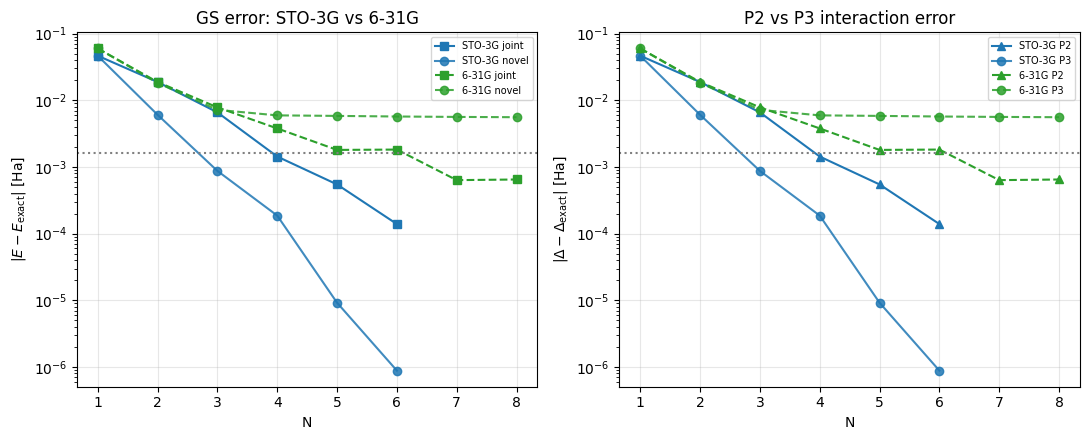

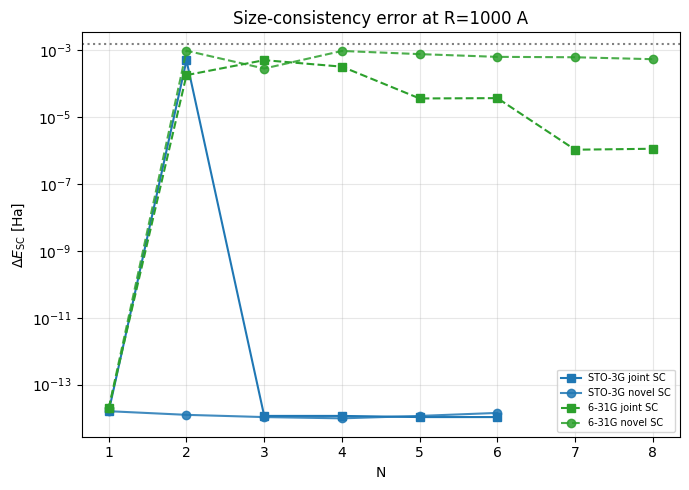

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
styles = {'sto-3g': ('C0', '-'), '6-31g': ('C2', '--')}
for basis in BASIS_LIST:
    c, ls = styles[basis]
    df = results[basis]['df_proto']
    lbl = BASIS_CONFIG[basis]['label']
    axes[0].semilogy(df['N'], df['gs_err_joint'], f's{ls}', color=c, label=f'{lbl} joint')
    axes[0].semilogy(df['N'], df['gs_err_novel'], f'o{ls}', color=c, alpha=0.85, label=f'{lbl} novel')
    axes[1].semilogy(df['N'], df['err_P2'], f'^{ls}', color=c, label=f'{lbl} P2')
    axes[1].semilogy(df['N'], df['err_P3'], f'o{ls}', color=c, alpha=0.85, label=f'{lbl} P3')
axes[0].axhline(CHEM_ACC, color='gray', ls=':')
axes[0].set_xlabel('N'); axes[0].set_ylabel(r'$|E-E_{\mathrm{exact}}|$ [Ha]')
axes[0].set_title('GS error: STO-3G vs 6-31G')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)
axes[1].axhline(CHEM_ACC, color='gray', ls=':')
axes[1].set_xlabel('N'); axes[1].set_ylabel(r'$|\Delta-\Delta_{\mathrm{exact}}|$ [Ha]')
axes[1].set_title('P2 vs P3 interaction error')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIG_ROOT, 'cross_basis_gs_and_int_error.png'), dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for basis in BASIS_LIST:
    c, ls = styles[basis]
    df = results[basis]['df_sc']
    lbl = BASIS_CONFIG[basis]['label']
    ax.semilogy(df['N'], np.maximum(df['SC_err_joint'], 1e-16), f's{ls}', color=c,
                label=f'{lbl} joint SC')
    ax.semilogy(df['N'], np.maximum(df['SC_err_novel'], 1e-16), f'o{ls}', color=c, alpha=0.85,
                label=f'{lbl} novel SC')
ax.axhline(CHEM_ACC, color='gray', ls=':')
ax.set_xlabel('N'); ax.set_ylabel(r'$\Delta E_{\mathrm{SC}}$ [Ha]')
ax.set_title('Size-consistency error at R=1000 A')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIG_ROOT, 'cross_basis_SC_error.png'), dpi=150)
plt.show()


## 6. Summary


In [14]:
summary_rows = []
for basis in BASIS_LIST:
    r = results[basis]
    df_proto, df_sc = r['df_proto'], r['df_sc']
    N_MAX = r['N_MAX']
    summary_rows.append({
        'basis': basis,
        'label': BASIS_CONFIG[basis]['label'],
        'N_max': N_MAX,
        'dimer_dim': r['dimer_dim'],
        'use_sparse': r['use_sparse'],
        'E_mono': r['E_mono'],
        'delta_exact_R1p1': r['delta_exact'],
        'err_P1_Nmax': float(df_proto.loc[df_proto['N'] == N_MAX, 'err_P1'].iloc[0]),
        'err_P2_Nmax': float(df_proto.loc[df_proto['N'] == N_MAX, 'err_P2'].iloc[0]),
        'err_P3_Nmax': float(df_proto.loc[df_proto['N'] == N_MAX, 'err_P3'].iloc[0]),
        'gs_err_joint_Nmax': float(df_proto.loc[df_proto['N'] == N_MAX, 'gs_err_joint'].iloc[0]),
        'gs_err_novel_Nmax': float(df_proto.loc[df_proto['N'] == N_MAX, 'gs_err_novel'].iloc[0]),
        'novel_raw_dim_Nmax': N_MAX * N_MAX,
        'SC_err_joint_peak': float(df_sc['SC_err_joint'].max()),
        'SC_err_novel_Nmax': float(df_sc.loc[df_sc['N'] == N_MAX, 'SC_err_novel'].iloc[0]),
        'P1_ne_P2': bool(r['p1_ne_p2']),
    })
df_sum = pd.DataFrame(summary_rows)
df_sum.to_csv(os.path.join(FIG_ROOT, 'summary.csv'), index=False)

print('=== Multibasis protocol comparison ===')
print(df_sum.to_string(index=False))
print()
print('Interpretation:')
print('  - Joint QKD is not size-consistent at finite N (see SC_err_joint peak).')
print('  - P1~P2 at large N is reference coincidence once E(R=1000)->2 E_mono_exact.')
print('  - STO-3G: novel P3 typically reaches ~uHa / machine precision.')
print('  - 6-31G: novel may plateau (mHa-scale) while joint keeps improving.')
print(f'Outputs: {FIG_ROOT}')


=== Multibasis protocol comparison ===
 basis  label  N_max  dimer_dim  use_sparse    E_mono  delta_exact_R1p1  err_P1_Nmax  err_P2_Nmax  err_P3_Nmax  gs_err_joint_Nmax  gs_err_novel_Nmax  novel_raw_dim_Nmax  SC_err_joint_peak  SC_err_novel_Nmax  P1_ne_P2
sto-3g STO-3G      6         64       False -1.137306          0.647096     0.000139     0.000139 8.830715e-07           0.000139       8.830715e-07                  36           0.000503       1.421085e-14      True
 6-31g  6-31G      8      16384        True -1.151614          0.524750     0.000648     0.000649 5.575276e-03           0.000649       5.575276e-03                  64           0.000512       5.474250e-04      True

Interpretation:
  - Joint QKD is not size-consistent at finite N (see SC_err_joint peak).
  - P1~P2 at large N is reference coincidence once E(R=1000)->2 E_mono_exact.
  - STO-3G: novel P3 typically reaches ~uHa / machine precision.
  - 6-31G: novel may plateau (mHa-scale) while joint keeps improving.
Output

### Conclusion checklist

- Both **STO-3G** (dense, dimer dim 64) and **6-31G** (sparse, dimer dim 16384) run the same three protocols.
- 6-31G uses sparse \(H\), `expm_multiply`, one-shot Krylov builds + slicing, and an \(O(N^2)\) product-grid builder — no dense diagonalization of the full Hamiltonian.
- Protocol 3 raw basis size is \(N^2\); joint uses size \(N\).
- Finite-\(N\) SC failure of joint QKD is shown at \(R=1000\); novel product grid is SC-friendly when \(H_{ab}\approx 0\).


## 7. Can we fix Protocol 3 without giving up the dressed idea?

**What went wrong on 6-31G?**

The novel method only uses vectors of the form

$$
\lvert\Phi_{ij}\rangle = U_A^{\,i}\, U_B^{\,j}\,\lvert\mathrm{HF}\rangle.
$$

When the two H$_2$ molecules sit close together ($R = 1.1\,\mathrm{\AA}$), the interaction $H_{ab}$ is large: dispersion, Pauli repulsion, and charge-transfer / polarization mix the fragments. A single fixed product ordering then becomes too restrictive. Many of those vectors become linearly dependent, so the *effective* subspace stops growing even though the *raw* count is $N^2$. The exact ground state needs a bit of *inter-fragment* entanglement (the chemistry that lives on both molecules at once) that this grid never fully reaches — and that effect is stronger in 6-31G than in STO-3G because the larger basis opens more virtual orbitals for charge transfer and dynamical correlation.

**What we keep:** dressed fragment Hamiltonians

$$
H_A = H_a + \tfrac{1}{2} H_{ab},
\qquad
H_B = H_b + \tfrac{1}{2} H_{ab},
$$

and evolution with $U_A = e^{-i H_A \Delta t}$ and $U_B = e^{-i H_B \Delta t}$. Chemically, dressing means each fragment “feels” half of the intermolecular interaction — similar in spirit to embedding / mean-field polarization of one monomer by the other — without evolving under the full dimer Hamiltonian for every Krylov vector.

**What we try next** (three small upgrades, from mild to stronger):

### 1. Both orderings (still fully dressed)

Also include the reversed product

$$
\lvert\Phi_{ij}^{\mathrm{BA}}\rangle = U_B^{\,j}\, U_A^{\,i}\,\lvert\mathrm{HF}\rangle.
$$

**Chemistry picture.** Even though $A$ and $B$ are identical H$_2$ monomers, the *dressed* operators share $H_{ab}$, so $[H_A, H_B] \neq 0$ at close contact. Evolving “$A$ then $B$” versus “$B$ then $A$” is like applying the polarization / response of each fragment in opposite sequence. Those two histories imprint different correlated amplitudes on $\lvert\mathrm{HF}\rangle$ (e.g. different mixtures of local excitations vs charge-transfer character). At large separation $H_{ab}\to 0$, the two orders become the same product states again — so this upgrade should not spoil size consistency in the non-interacting limit.

### 2. Several timesteps (still fully dressed)

Build the same dressed AB grid at more than one $\Delta t$ (e.g. $0.5\,\Delta t$, $\Delta t$, $1.5\,\Delta t$), then take the union.

**Chemistry picture.** Molecular spectra have several energy scales: bonding / antibonding gaps inside each H$_2$, intermolecular coupling, and higher virtual excitations opened by 6-31G. A single timestep is like sampling the time-dependent Schrödinger equation on one clock. Extra $\Delta t$ values are a cheap way to resolve more of that spectral content — analogous to using several frequencies in response theory — without changing *which* operators ($H_A$, $H_B$) we use. This helps when vectors at one $\Delta t$ are nearly linearly dependent; it does *not* by itself invent new entanglement grammar if the product ordering is still the bottleneck.

### 3. Hybrid: dressed grid + short joint Krylov

Keep the dressed product grid, and add a short *joint* Krylov chain on the full dimer Hamiltonian $H_{\mathrm{tot}}$:

$$
\mathcal{K}^{\mathrm{hybrid}}
= \mathrm{span}\!\Big(
\{\lvert\Phi_{ij}\rangle\}
\;\cup\;
\{U_{\mathrm{tot}}^{k}\lvert\mathrm{HF}\rangle\}_{k=0}^{N-1}
\Big),
\qquad
U_{\mathrm{tot}} = e^{-i H_{\mathrm{tot}} \Delta t}.
$$

**Chemistry picture.** The dressed block still encodes fragment-local correlation and a mean-field-like treatment of $H_{ab}$. The joint patch is allowed to explore *true intermolecular* entanglement — charge-transfer, simultaneous excitations on both monomers, and other “blocking” corrections that a product of fragment evolutions struggles to build. Think of it as: fragment embedding for most of the space, plus a few supermolecular Krylov vectors to recover the residual interaction energy. The tradeoff is that those joint vectors are no longer pure fragment evolutions; the hope is that a *short* joint chain is enough once the dressed grid has done the heavy lifting.

We rebuild only the $R = 1.1\,\mathrm{\AA}$ systems for these tests (the main run deleted the large Hamiltonians to save memory).


In [15]:
# ---------------------------------------------------------------------------
# Protocol 3 enrichment helpers
# Reuse the same sparse/dense machinery as the main notebook.
# ---------------------------------------------------------------------------

def build_product_states_BA(H_A, H_B, ref, N, dt, use_sparse=False):
    """Opposite-order dressed grid: |Phi_ij> = U_B^j U_A^i |HF>.

    When [H_A, H_B] != 0, this is *not* the same as U_A^i U_B^j |HF>.
    Including both orderings can open new directions while staying dressed.
    """
    if use_sparse:
        # Build A-chain first: |a_i> = U_A^i |HF>
        ref = ref.astype(complex)
        a_chain = [ref.copy()]
        for _ in range(1, N):
            a_chain.append(expm_multiply(-1j * dt * H_A, a_chain[-1]))
        # Then apply U_B^j to each |a_i>
        states = []
        for i in range(N):
            for j in range(N):
                state = a_chain[i]
                for _ in range(j):
                    state = expm_multiply(-1j * dt * H_B, state)
                states.append(state)
        return states

    # Dense path: matrix powers
    U_A = la.expm(-1j * dt * H_A)
    U_B = la.expm(-1j * dt * H_B)
    a_chain = [ref.copy().astype(complex)]
    for _ in range(1, N):
        a_chain.append(U_A @ a_chain[-1])
    b_ops = [np.eye(H_B.shape[0], dtype=complex)]
    for _ in range(1, N):
        b_ops.append(U_B @ b_ops[-1])
    return [b_ops[j] @ a_chain[i] for i in range(N) for j in range(N)]


def build_both_order_states(sys, N):
    """Union of AB-order and BA-order dressed grids (raw size up to 2 N^2)."""
    HA, HB = _H_A_of(sys), _H_B_of(sys)
    us = sys['use_sparse']
    dt = sys['dt_tot']
    ref = sys['ref']
    if us:
        ab = build_product_states_sparse(HA, HB, ref, N, dt)
    else:
        ab = build_product_states_dense(HA, HB, ref, N, dt)
    ba = build_product_states_BA(HA, HB, ref, N, dt, use_sparse=us)
    return ab + ba


def build_multidt_states(sys, N, dt_scales=(0.5, 1.0, 1.5)):
    """Dressed AB grid at several timesteps; concatenate all of them.

    One Delta-t can make consecutive Krylov vectors look similar.
    A few different Delta-t values explore the spectrum more evenly.
    """
    HA, HB = _H_A_of(sys), _H_B_of(sys)
    us = sys['use_sparse']
    ref = sys['ref']
    dt0 = sys['dt_tot']
    states = []
    for scale in dt_scales:
        dt = dt0 * scale
        if us:
            states.extend(build_product_states_sparse(HA, HB, ref, N, dt))
        else:
            states.extend(build_product_states_dense(HA, HB, ref, N, dt))
    return states


def build_hybrid_states(sys, N, n_joint=None):
    """Dressed novel grid PLUS a short joint Krylov chain on H_tot.

    Dressed part: size-consistency-friendly product structure.
    Joint part: small patch that can reach entangled corrections the grid misses.
    """
    if n_joint is None:
        n_joint = N
    HA, HB = _H_A_of(sys), _H_B_of(sys)
    H = _H_tot_of(sys)
    us = sys['use_sparse']
    ref = sys['ref']
    dt = sys['dt_tot']
    if us:
        novel = build_product_states_sparse(HA, HB, ref, N, dt)
        joint = build_krylov_states_sparse(H, ref, n_joint, dt)
    else:
        novel = build_product_states_dense(HA, HB, ref, N, dt)
        joint = build_krylov_states(H, ref, n_joint, dt)
    return novel + joint


def energy_from_state_list(sys, states):
    """Ritz energy of H_tot in the span of `states` (+ nuclear repulsion)."""
    H = _H_tot_of(sys)
    return energy_from_states(H, states, sys['E_nuc'], use_sparse=sys['use_sparse'])


print('Enrichment helpers ready:')
print('  - both orderings (AB + BA)')
print('  - multi-Delta-t dressed grid')
print('  - hybrid (dressed + joint)')


Enrichment helpers ready:
  - both orderings (AB + BA)
  - multi-Delta-t dressed grid
  - hybrid (dressed + joint)


### 7a. Run the three enrichment variants at $R = 1.1\,\mathrm{\AA}$

For each basis we rebuild the interacting dimer, sweep $N$, and compare:

- **novel** — original Protocol 3 (one product order, one $\Delta t$):
  $$\lvert\Phi_{ij}\rangle = U_A^{i}\, U_B^{j}\,\lvert\mathrm{HF}\rangle$$
- **both_order** — AB + BA grids (opposite polarization / response sequences):
  $$\mathrm{span}\!\big(\{U_A^{i} U_B^{j}\lvert\mathrm{HF}\rangle\} \cup \{U_B^{j} U_A^{i}\lvert\mathrm{HF}\rangle\}\big)$$
- **multidt** — AB grid at three $\Delta t$ scales (several spectral “clocks”):
  e.g. $0.5\,\Delta t$, $\Delta t$, $1.5\,\Delta t$
- **hybrid** — dressed fragment physics + a short supermolecular Krylov patch:
  $$\mathrm{span}\!\big(\{\lvert\Phi_{ij}\rangle\} \cup \{U_{\mathrm{tot}}^{k}\lvert\mathrm{HF}\rangle\}_{k=0}^{N-1}\big)$$

We also keep **joint** in the table so you can see how close each fix gets to ordinary supermolecular QKD.


In [16]:
# Output folder for enrichment figures / CSVs
ENRICH_DIR = os.path.join(FIG_ROOT, 'enrichment')
os.makedirs(ENRICH_DIR, exist_ok=True)

# Variants we will compare (name -> builder)
# "novel" and "joint" are controls; the other three are the proposed fixes.
VARIANT_BUILDERS = {
    'novel':      lambda sys, N: (
        build_product_states_sparse(_H_A_of(sys), _H_B_of(sys), sys['ref'], N, sys['dt_tot'])
        if sys['use_sparse'] else
        build_product_states_dense(_H_A_of(sys), _H_B_of(sys), sys['ref'], N, sys['dt_tot'])
    ),
    'both_order': build_both_order_states,
    'multidt':    build_multidt_states,
    'hybrid':     build_hybrid_states,
    'joint':      lambda sys, N: (
        build_krylov_states_sparse(_H_tot_of(sys), sys['ref'], N, sys['dt_tot'])
        if sys['use_sparse'] else
        build_krylov_states(_H_tot_of(sys), sys['ref'], N, sys['dt_tot'])
    ),
}

# On 6-31G, both_order / multidt can get expensive at large N.
# Use a slightly shorter sweep for those, full N_MAX for hybrid + controls.
ENRICH_N_MAX = {
    'sto-3g': 6,
    '6-31g':  6,   # N=6 => novel 36, both_order 72, multidt 108; laptop-friendly
}

enrich_rows = []
enrich_systems = {}  # keep R=1.1 systems for optional follow-ups

for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    N_max = ENRICH_N_MAX[basis]
    dims = list(range(1, N_max + 1))
    print('=' * 60)
    print(f'Enrichment sweep: {label}  (N = 1..{N_max})')
    print('=' * 60)

    # Rebuild monomer + interacting dimer only (not the full R list)
    mono, systems = build_all_systems(basis, [R_INT])
    sys = systems[R_INT]
    enrich_systems[basis] = sys
    E_exact = sys['gs_total']
    E_mono_sum = 2.0 * mono['gs_total']
    delta_exact = sys['delta_exact']
    print(f'  dim={sys["joint_dim"]}, sparse={sys["use_sparse"]}, '
          f'E_exact={E_exact:.8f}, Delta_exact={delta_exact:.6f}')

    for N in dims:
        print(f'  N={N} ...', end=' ', flush=True)
        for name, builder in VARIANT_BUILDERS.items():
            states = builder(sys, N)
            out = energy_from_state_list(sys, states)
            # Protocol-3-style interaction: E_method - 2 E_mono (exact)
            delta = out['gs_total'] - E_mono_sum
            enrich_rows.append({
                'basis': basis,
                'label': label,
                'N': N,
                'variant': name,
                'raw_dim': out['raw_dim'],
                'eff_dim': out['eff_dim'],
                'gs_total': out['gs_total'],
                'gs_err': abs(out['gs_total'] - E_exact),
                'delta': delta,
                'err_int': abs(delta - delta_exact),  # same as gs_err with exact monomers
            })
            print(f'{name}(eff={out["eff_dim"]}, err={abs(out["gs_total"]-E_exact):.2e})', end='  ')
        print()
        gc.collect()

    # Free the large H after this basis (keep only summary rows)
    del systems, mono
    gc.collect()
    print(f'  Done {label}.\n')

df_enrich = pd.DataFrame(enrich_rows)
df_enrich.to_csv(os.path.join(ENRICH_DIR, 'enrichment_sweep_R1p1.csv'), index=False)
print('Saved:', os.path.join(ENRICH_DIR, 'enrichment_sweep_R1p1.csv'))
print()
# Quick peek at the largest N for each basis
for basis in BASIS_LIST:
    sub = df_enrich[(df_enrich['basis'] == basis) &
                    (df_enrich['N'] == ENRICH_N_MAX[basis])]
    print(f"--- {BASIS_CONFIG[basis]['label']} at N={ENRICH_N_MAX[basis]} ---")
    print(sub[['variant', 'raw_dim', 'eff_dim', 'gs_err', 'err_int']].to_string(
        index=False, float_format=lambda x: f'{x:.4e}'))
    print()


Enrichment sweep: STO-3G  (N = 1..6)
  dim=64, sparse=False, E_exact=-1.62751587, Delta_exact=0.647096
  N=1 ... novel(eff=1, err=4.66e-02)  both_order(eff=1, err=4.66e-02)  multidt(eff=1, err=4.66e-02)  hybrid(eff=1, err=4.66e-02)  joint(eff=1, err=4.66e-02)  
  N=2 ... novel(eff=4, err=6.07e-03)  both_order(eff=5, err=5.11e-03)  multidt(eff=10, err=2.74e-04)  hybrid(eff=5, err=5.09e-03)  joint(eff=2, err=1.88e-02)  
  N=3 ... novel(eff=9, err=8.74e-04)  both_order(eff=13, err=1.48e-04)  multidt(eff=17, err=3.38e-05)  hybrid(eff=11, err=3.70e-04)  joint(eff=3, err=6.59e-03)  
  N=4 ... novel(eff=16, err=1.87e-04)  both_order(eff=24, err=1.60e-06)  multidt(eff=23, err=2.39e-06)  hybrid(eff=19, err=3.49e-05)  joint(eff=4, err=1.43e-03)  
  N=5 ... novel(eff=21, err=9.21e-06)  both_order(eff=27, err=2.24e-08)  multidt(eff=26, err=8.10e-08)  hybrid(eff=25, err=2.22e-07)  joint(eff=5, err=5.47e-04)  
  N=6 ... novel(eff=25, err=8.83e-07)  both_order(eff=31, err=5.92e-10)  multidt(eff=30, e

### 7b. Plots: do the fixes lower the error?

- **Left:** ground-state error $\lvert E - E_{\mathrm{exact}}\rvert$ versus $N$.
- **Right:** effective subspace dimension (rank of the overlap matrix $S$) versus $N$ — are we actually gaining new directions?

Chemical accuracy ($1.6\,\mathrm{mHa}$) is drawn as a dotted line on the error plots.


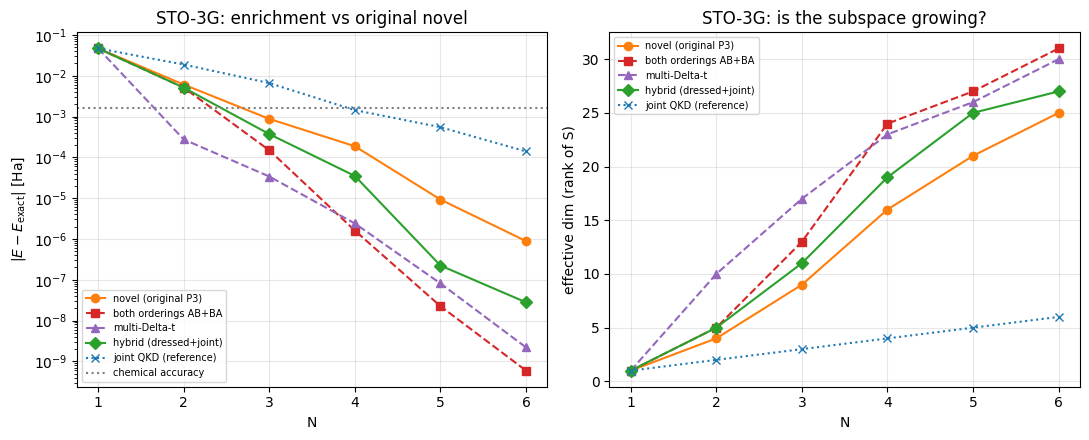

Saved /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_interacting_protocols_multibasis/enrichment/enrichment_sto3g_R1p1.png


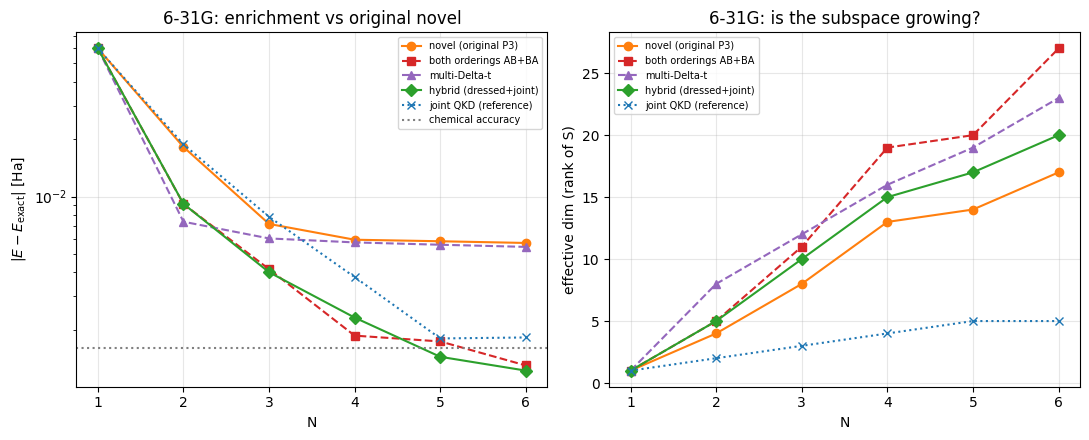

Saved /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_interacting_protocols_multibasis/enrichment/enrichment_631g_R1p1.png


In [17]:
# Colour / marker style per variant
STYLE = {
    'novel':      ('C1', 'o-',  'novel (original P3)'),
    'both_order': ('C3', 's--', 'both orderings AB+BA'),
    'multidt':    ('C4', '^--', 'multi-Delta-t'),
    'hybrid':     ('C2', 'D-',  'hybrid (dressed+joint)'),
    'joint':      ('C0', 'x:',  'joint QKD (reference)'),
}

for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    sub = df_enrich[df_enrich['basis'] == basis].copy()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # --- Left: GS / interaction error (identical with exact monomers) ---
    ax = axes[0]
    for name, (color, ls, legend) in STYLE.items():
        s = sub[sub['variant'] == name].sort_values('N')
        ax.semilogy(s['N'], np.maximum(s['gs_err'], 1e-16), ls, color=color, label=legend)
    ax.axhline(CHEM_ACC, color='gray', ls=':', label='chemical accuracy')
    ax.set_xlabel('N')
    ax.set_ylabel(r'$|E - E_{\mathrm{exact}}|$ [Ha]')
    ax.set_title(f'{label}: enrichment vs original novel')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # --- Right: effective dimension (did the span actually grow?) ---
    ax = axes[1]
    for name, (color, ls, legend) in STYLE.items():
        s = sub[sub['variant'] == name].sort_values('N')
        ax.plot(s['N'], s['eff_dim'], ls, color=color, label=legend)
    ax.set_xlabel('N')
    ax.set_ylabel('effective dim (rank of S)')
    ax.set_title(f'{label}: is the subspace growing?')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    out_path = os.path.join(ENRICH_DIR, f'enrichment_{basis.replace("-", "")}_R1p1.png')
    fig.savefig(out_path, dpi=150)
    plt.show()
    print('Saved', out_path)


### 7c. Side-by-side: STO-3G vs 6-31G at max $N$

A bar chart of the ground-state error for each variant at the largest $N$ used in the enrichment sweep.

The question to ask: **which fix gets 6-31G under chemical accuracy ($1.6\,\mathrm{mHa}$) while staying mostly dressed?**


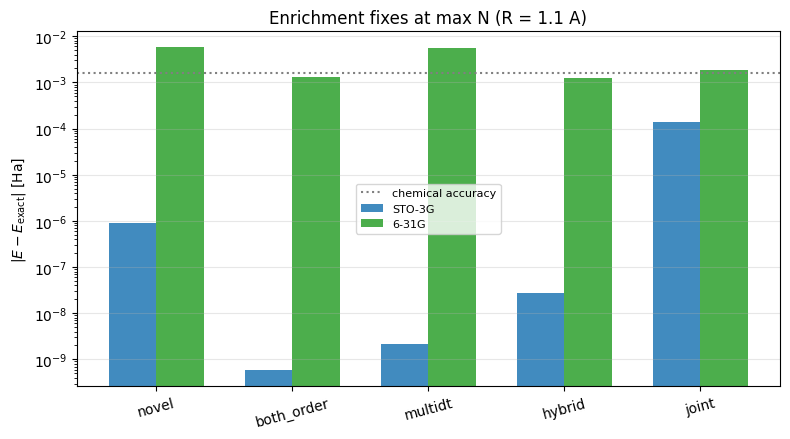

Saved /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_interacting_protocols_multibasis/enrichment/enrichment_bar_maxN.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
variants = ['novel', 'both_order', 'multidt', 'hybrid', 'joint']
x = np.arange(len(variants))
width = 0.35

for offset, basis, color in [( -width/2, 'sto-3g', 'C0'), (width/2, '6-31g', 'C2')]:
    N_max = ENRICH_N_MAX[basis]
    errs = []
    for v in variants:
        row = df_enrich[(df_enrich['basis'] == basis) &
                        (df_enrich['N'] == N_max) &
                        (df_enrich['variant'] == v)]
        errs.append(float(row['gs_err'].iloc[0]) if len(row) else np.nan)
    ax.bar(x + offset, errs, width, label=BASIS_CONFIG[basis]['label'], color=color, alpha=0.85)

ax.axhline(CHEM_ACC, color='gray', ls=':', label='chemical accuracy')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(variants, rotation=15)
ax.set_ylabel(r'$|E - E_{\mathrm{exact}}|$ [Ha]')
ax.set_title('Enrichment fixes at max N (R = 1.1 A)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
bar_path = os.path.join(ENRICH_DIR, 'enrichment_bar_maxN.png')
fig.savefig(bar_path, dpi=150)
plt.show()
print('Saved', bar_path)


### 7d. What did we learn?

A short printed summary comparing each fix to the original novel Protocol 3.

For each variant we report
$\lvert E - E_{\mathrm{exact}}\rvert$
and the ratio of effective to raw dimension,
$\mathrm{eff\_dim}\,/\,\mathrm{raw\_dim}$.


In [19]:
print('=== Protocol 3 enrichment summary ===')
print('Interaction error with exact monomers equals GS error here.')
print()
for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    N_max = ENRICH_N_MAX[basis]
    sub = df_enrich[(df_enrich['basis'] == basis) & (df_enrich['N'] == N_max)]
    novel_err = float(sub.loc[sub['variant'] == 'novel', 'gs_err'].iloc[0])
    print(f'{label} at N={N_max} (novel error = {novel_err:.3e} Ha):')
    for v in ['both_order', 'multidt', 'hybrid', 'joint']:
        row = sub[sub['variant'] == v].iloc[0]
        ratio = novel_err / row['gs_err'] if row['gs_err'] > 0 else np.inf
        better = 'better' if row['gs_err'] < novel_err else 'similar/worse'
        under = 'YES' if row['gs_err'] < CHEM_ACC else 'no'
        print(f"  {v:12s}  err={row['gs_err']:.3e}  "
              f"eff_dim={int(row['eff_dim']):3d}/{int(row['raw_dim']):3d}  "
              f"vs novel: {ratio:.1f}x {better}  | chem.acc? {under}")
    print()

print('Takeaways:')
print('  1. both_order / multidt stay fully dressed; they help only if eff_dim grows.')
print('  2. hybrid adds a joint patch: usually the biggest drop in error on 6-31G.')
print('  3. If hybrid works but both_order does not, the bottleneck really was the')
print('     ordered-product grammar (missing entanglement), not just timestep choice.')
print(f'Figures and CSV: {ENRICH_DIR}')

# Write a one-row-per-variant summary CSV
sum_rows = []
for basis in BASIS_LIST:
    N_max = ENRICH_N_MAX[basis]
    sub = df_enrich[(df_enrich['basis'] == basis) & (df_enrich['N'] == N_max)]
    for _, row in sub.iterrows():
        sum_rows.append({
            'basis': basis, 'N': N_max, 'variant': row['variant'],
            'raw_dim': row['raw_dim'], 'eff_dim': row['eff_dim'],
            'gs_err': row['gs_err'], 'below_chem_acc': row['gs_err'] < CHEM_ACC,
        })
pd.DataFrame(sum_rows).to_csv(os.path.join(ENRICH_DIR, 'enrichment_summary.csv'), index=False)


=== Protocol 3 enrichment summary ===
Interaction error with exact monomers equals GS error here.

STO-3G at N=6 (novel error = 8.831e-07 Ha):
  both_order    err=5.921e-10  eff_dim= 31/ 72  vs novel: 1491.4x better  | chem.acc? YES
  multidt       err=2.194e-09  eff_dim= 30/108  vs novel: 402.4x better  | chem.acc? YES
  hybrid        err=2.791e-08  eff_dim= 27/ 42  vs novel: 31.6x better  | chem.acc? YES
  joint         err=1.392e-04  eff_dim=  6/  6  vs novel: 0.0x similar/worse  | chem.acc? YES

6-31G at N=6 (novel error = 5.713e-03 Ha):
  both_order    err=1.300e-03  eff_dim= 27/ 72  vs novel: 4.4x better  | chem.acc? YES
  multidt       err=5.449e-03  eff_dim= 23/108  vs novel: 1.0x better  | chem.acc? no
  hybrid        err=1.222e-03  eff_dim= 20/ 42  vs novel: 4.7x better  | chem.acc? YES
  joint         err=1.824e-03  eff_dim=  5/  6  vs novel: 3.1x better  | chem.acc? no

Takeaways:
  1. both_order / multidt stay fully dressed; they help only if eff_dim grows.
  2. hybrid add

### Enrichment checklist

- We kept the **dressed** fragment operators $H_A$ and $H_B$ in every fix.
- **Both orderings** and **multi-$\Delta t$** stay fully dressed; watch whether $\mathrm{eff\_dim}$ grows with $N$.
- **Hybrid** is the pragmatic fix: dressed core + a short joint Krylov patch for missing entanglement.
- Success on 6-31G means getting under chemical accuracy ($1.6\,\mathrm{mHa}$) without throwing away the size-consistency idea at large $R$.
